##**10. 회귀**

<br>

###**01. 회귀 소개**

: 여러 개의 독립 변수와 한 개의 종속 변수 간의 상관관계를 모델링하는 기법을 통칭.



> 주어진 피처와 결정 값 데이터 기반에서 학습을 통해 최적의 회귀 계수를 찾아내는 것

* 단일 회귀
* 다중 회귀
* 선형 회귀
* 비선형 회귀

--> 실제 값과 예측값의 차이 (잔차)를 최소화하는 직선형 회귀선을 최적화하는 방식

<br>

###**02. 단순 선형 회귀를 통한 회귀 이해**

**단순 선형 회귀**: 독립변수도 하나, 종속변수도 하나인 선형 회귀

-> 독립변수가 1개인 단순 선형 회귀에서는 기울기 w1, 절편 w0을 회귀 계수로 지칭

-> 오류합 계산 시 오류 값의 제곱을 구해서 더하는 방식 즉, RSS 방식을 활용함.

<br>

###**03. 비용 최소화하기 - 경사하강법 소개**

**경사하강법**: 고차원 방정식에
대한 문제를 해결해 주면서 비용 함수 RSS를 최소화하는 방법을 직관적으로 제공하는 뛰어난 방식

-> 예측값과 실제 값의 차이가 작아지는 방향성을 가지고 w 파라미터를 지속해서 보정해 나감

-> 즉, 최초 w에서부터 미분을 적용한 뒤 이 미분 값이 계소 감소하는 방향으로 순차적으로 w를 업데이트. 더이상 미분된 기울기가 감소하지 않는 지점을 비용 함수가 최소인 지점으로 간주하고 그때의 w을 반환 (변수 여러개일때 각 변수에 대해 편미분 적용)

-> 미분 시 편미분 값이 너무 클 수 있기 때문에 보정 계수를 곱하는데 이를 '학습률'이라고 함.

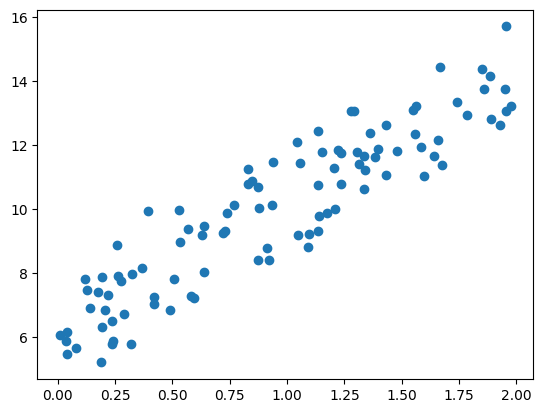

In [ ]:
import numpy as np
import matplotlib.pyplot as pit
%matplotlib inline

np.random.seed(0)
# y = 4X + 6 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦.
X = 2 * np.random.rand(100,1)
y = 6 + 4 * X+np.random.randn(100,1)

# X, y 데이터 세트 산점도로 시각화
pit.scatter(X, y)

In [ ]:
def get_cost(y, y_pred):
  N = len(y)
  cost = np.sum(np.square(y - y_pred))/N
  return cost

경사하강법을 gradient_descent()라는 함수를 생성해 구현


In [ ]:
# w1과 w0를 업데이트할 w1_update, wo_update를 반환.
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
  N = len(y)
  # 먼저 w1_update, w0_update를 각각 w1, w0 shape 동일한 크기를 가진 0 값으로 초기화
  w1_update = np.zeros_like(w1)
  w0_update = np.zeros_like(w0)
  # 예측 배열 계산하고 예측과 실제 값의 차이 계산
  y_pred = np.dot(X, w1 .T) + w0
  diff = y-y_pred

  # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
  w0_factors = np.ones((N, 1))
  # w1과 w0을 업데이트할 w1_update와 w0_update 계산
  w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
  w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))

  return w1_update, w0_update

In [ ]:
# 입력 인자 iters 주어진 횟수만큼 반복적으로 w1 w0 업데이트 적용함.
def gradient_descent_steps(X, y, iters=10000):
  # w0 w1 모두 0으로 초기화.
  w0 = np.zeros((1, 1))
  w1 = np.zeros((1, 1))

  # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행.
  for ind in range(iters):
      w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
      w1 = w1 - w1_update
      w0 = w0 - w0_update
  return w1, w0

In [ ]:
def get_cost(y, y_pred):
  N = len(y)
  cost = np.sum(np.square(y - y_pred))/N
  return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1 [0, 0], w0[0, 0]))
y_pred = w1 [0, 0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


실제 선형식인 y=4X+6과 유사하게 w1, w0 도출됨.

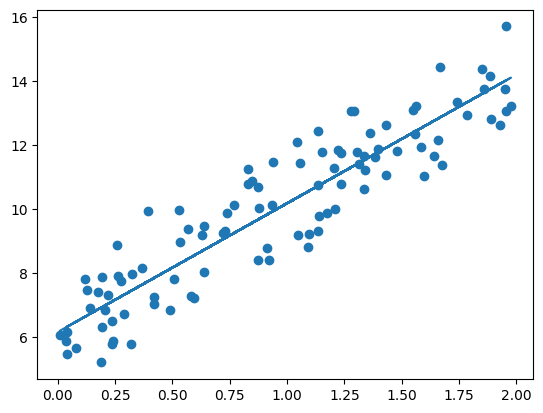

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, y_pred)

-> 일반적으로 경사 하강법은 모든 학습 데이터에 대해 반복적으로 비용함수 최소화를 위한 값을 업데이트하기 때문에 수행 시간이 매우 오래걸린다는 단점이 존재.

-> 따라서 실전에서는 대부분 **확률적 경사 하강법**을 이용
: 일부 데이터만 이용해 w가 업데이트되는 값을 계산하므로 경사 하강법에 비해 빠른 속도를 보장

In [18]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
  w0 = np.zeros((1, 1))
  w1 = np.zeros((1, 1))

  for ind in range(iters):
    np.random.seed(ind)
    # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sampler 저장
    stochastic_random_index = np.random.permutation(X.shape[0])
    sample_X = X[stochastic_random_index[0:batch_size]]
    sample_y = y[stochastic_random_index[0:batch_size]]
    # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 업데이트
    w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
    w1 = w1 - w1_update
    w0 = w0 - w0_update

  return w1, w0

In [20]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:", round(w1[0, 0], 3), "w0:", round(w0[0, 0], 3))
y_pred = w1 [0, 0] * X + w0
print('Stochastic Gradient Descent Total Cost {0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost 0.9937


확률적 경사 하강법으로 구한 w0, w1 결과는 경사 하강법으로 구한 것과 큰 차이가 없으며, 예측 오류 비용 또한 경사하강법으로 구한 예측 오류 비용보다 아주 조금 높을 뿐으로 큰 예측 성능상의 차이가 없음을 알 수 있음.

###**04. 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측**

**LinearRegression 클래스 - Ordinary Least Squares**

**LinearRegression 클래스**는 예측값과 실제 값의 RSS를 최소화해 OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스

In [22]:
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression(fit_intercept=True, n_jobs=1)

Ordinary Least Squares 기반의 회귀 계수 계산은 입력 피처의 독립성에 많은 영향을 받음.

피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져서 오류에 매우 민감해지는데, 이러한 현상을 **다중공선성(multi-collinearity)** 문제라고 함.

**회귀 평가 지표**

- MAE: 편차 절댓값 변환 후 평균

-> metrics.mean_absolute_error

- MSE: 편차 제곱 합 후 평균

-> metrics.mean_squared_error

- RMSE: MSE에 루트 씌운 것

-> MSE API에 squared 파라미터를 False로 설정

- R^2: 분산 기반 예측 성능 평가

-> metrics.r2_score

<br>

**LinearRegression을 이용해 보스턴 주택 가격 회귀 구현**



In [26]:
import numpy as np
import matplotlib.pyplot as pit
import pandas as pd
import seaborn as sns
from scipy import stats
# from sklearn.datasets import load_boston  # Removed due to ethical concerns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# boston 데이터 세트 로드
# boston = load_boston() # Removed due to ethical concerns

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
bostonDF = pd.DataFrame(data, columns=feature_names)
bostonDF['PRICE'] = target

print('Boston 데이터 세트 크기 :', bostonDF.shape)
display(bostonDF.head())

Boston 데이터 세트 크기 : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


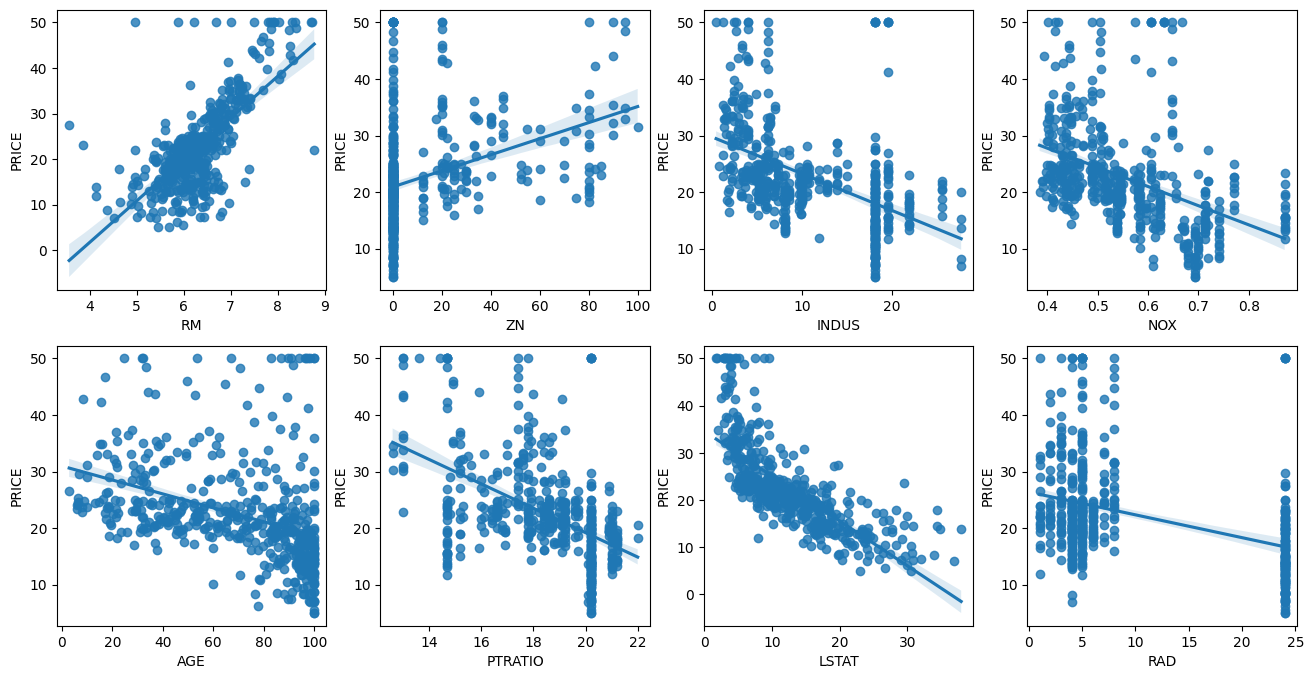

In [29]:
# 2개의 행과 4개의 열을 가진 subplots 이용. axs 4x2개의 ax 가짐 .
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
  row = int(i/4)
  col = i%4
  # 시본의 regplot 이용해 산점도와 선형 회귀 직선을 함께 표현
  sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

다른 칼럼보다 RM(양의 선형성)과 LSTAT(음의 선형성)의 PRICE 영향도가 가장 두드러지게 나타남.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

# 선형 회귀 OLS로 학습/예측/평가 수행.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE {1:.3F}'.format(mse, rmse))
print('Variance score: {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.297, RMSE 4.159
Variance score: 0.757


In [31]:
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_,1))

절편 값: 40.995595172164826
회귀 계수값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [32]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)

,0
RM,3.4
CHAS,3.0
RAD,0.4
ZN,0.1
INDUS,0.0
B,0.0
TAX,-0.0
AGE,0.0
CRIM,-0.1
LSTAT,-0.6


cross_val_score()를 이용해 교차 검증으로 MSE와 RMSE 측정

In [35]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 폴드 세트로 MSE 구한 뒤 이를 기반으로 다시 RMSE 구함.
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수
print('5 folds 개별 Negative MSE scores:', np.round(neg_mse_scores,2))
print('5 folds 개별 RMSE scores:', np.round(rmse_scores, 2))
print('5 folds 평균 RMSE : {0:.3f}'.format(avg_rmse))

5 folds 개별 Negative MSE scores: [-12.46 -26.05 -33.07 -80.76 -33.31]
5 folds 개별 RMSE scores: [3.53 5.1  5.75 8.99 5.77]
5 folds 평균 RMSE : 5.829


###**다항 회귀와 과(대)적합/과소적합 이해**

회귀가 독립변수의 단항식이 아닌 2차, 3차 방정식과 같은 다항식으로 표현되는 것을 다항 회귀라고 함.

[주의] 다항 회귀는 선형 회귀



In [36]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0, 1], [2, 3]] 2X2 행렬 생성
X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처:\n', X )

# degree = 2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2 다항식 계수 피처:\n', poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


이렇게 변환된 polynominal 피처에 선형 회귀를 적용해 다항 회귀를 구현

In [39]:
def polynomial_func(X):
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [42]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3 다항식 계수 feature \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape:', model.coef_.shape)

3 다항식 계수 feature 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape: (10,)


일차 단항식 계수 피처는 2개였지만, 3차 다항식 polynominal 변환 이후에는 다항식 계수 피처가 10개로 늘어남.



In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

# Pipeline 객체로 Streamline하게 Polynomial Feature 변환과 Linear Regression 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


**다항 회귀를 이용한 과소적합 및 과적합 이해**

다항 회귀의 차수(degree)가 높아질수록 과적합의 문제가 크게 발생

In [46]:
import numpy as np
import matplotlib.pyplot as pit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
  return np.cos(1.5 * np.pi * X)

# 수는 0부터 1 까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 tr e_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 0.4077289625098685 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 0.04320874987232064 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08] 입니다.
Degree 15 MSE 181238256.56423894 입니다.


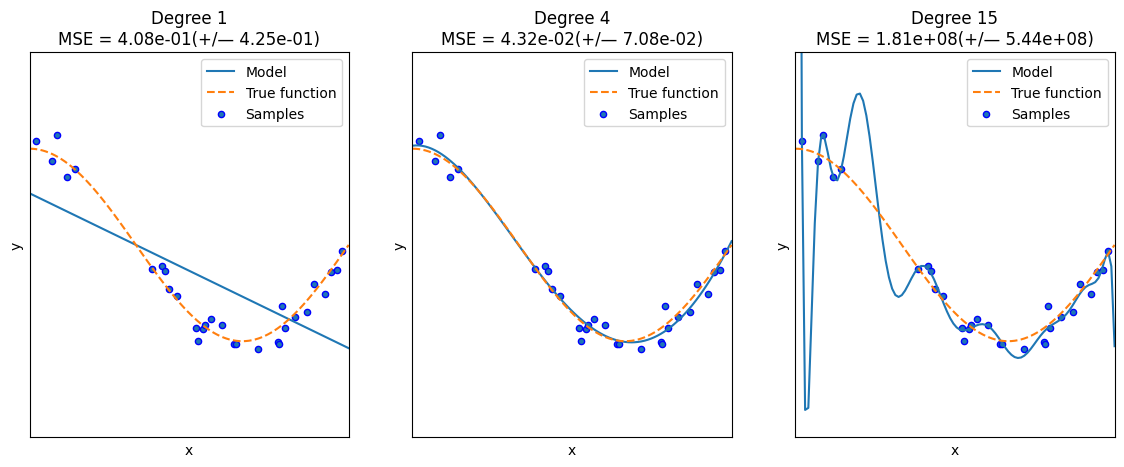

In [49]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree) 1, 4, 15 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
  ax = plt.subplot(1, len(degrees), i + 1)
  plt.setp(ax, xticks=(), yticks=())

  # 개별 degree별로 Polynomial 변환합니다.
  polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
  linear_regression = LinearRegression()
  pipeline = Pipeline([("polynomial_features", polynomial_features), ("linear_regression", linear_regression)])
  pipeline.fit(X.reshape(-1, 1), y)

  # 교차 검증으로 다항 회귀를 평가합니다.
  scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
  # Pipeline 구성하는 세부 객체를 접근하는 named_steps[’객체명']을 이용해 회귀계수 추출
  coefficients = pipeline.named_steps['linear_regression'].coef_
  print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
  print('Degree {0} MSE {1} 입니다.'.format(degrees[i], -1 *np.mean(scores)))

  # 0 부터 1 까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
  # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
  X_test = np.linspace(0, 1, 100)
  # 예측값 곡선
  plt.plot(X_test, pipeline.predict(X_test[:,np.newaxis]), label ="Model")
  # 실제 값 곡선
  plt.plot(X_test, true_fun(X_test), '--', label="True function")
  plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

  plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1 )); pit.ylim((-2, 2)); pit.legend(loc="best")
  plt.title("Degree {}\nMSE = {:.2e}(+/— {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()

- Degree 1 예측 곡선: 단순 선형 회귀와 동일. 직선으로 예측하기에는 너무 단순해보임. 예측 곡선이 학습 데이터의 패턴을 제대로 반영하지 못하고 있는 과소적합 모델 형성.

- Degree 4 예측 곡선: 실제 데이터 세트와 유사한 모습. 데이터를 잘 예측한 곡선이라고 할 수 있음.

- Degree 15 예측 곡선: MSE 값이 18258....이 되는 어처구니없는 오류 값 발생. 데이터 세트의 변동 잡음 값을 지나치게 반영한 결과, 예측 곡선이 학습 데이터 세트만 정확히 예측하고, 테스트 값의 실제 곡선과는 완전히 다른 형태의 예측 곡선이 만들어짐. 과적합이 심한 모델이 되어버림.

<br>

**편향-분산 트레이드오프**

degree 1과 같은 모델 - 고편향성을 지님
degree 15와 같은 모델 - 고분산성을 가짐

-> 일반적으로 편향과 분산은 한쪽이 높으면 한쪽이 낮아지는 경향이 있음. 즉 편향이 높으면 분산은 낮아지고(과소적합), 반대로 분산이 높으면 편향이 낮아짐 (과적합)

